In [18]:
#  1. Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns   

import nltk
from nltk.corpus import stopwords, twitter_samples
from nltk.stem import PorterStemmer
from nltk.tokenize import TweetTokenizer
import string
import re
from collections import defaultdict

nltk.download('twitter_samples')
nltk.download('stopwords')

print("Libraries imported successfully.")   


Libraries imported successfully.


[nltk_data] Downloading package twitter_samples to
[nltk_data]     /Users/macbook/nltk_data...
[nltk_data]   Package twitter_samples is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/macbook/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [19]:
# 2. Load the tweet dataset

# Load the positive and negative tweets 
all_positive_tweets = twitter_samples.strings('positive_tweets.json')
all_negative_tweets = twitter_samples.strings('negative_tweets.json')

# Split the data into training (first 4000)and testing sets (last 1000)
train_pos = all_positive_tweets[:4000]
test_pos = all_positive_tweets[4000:]
train_neg = all_negative_tweets[:4000]
test_neg = all_negative_tweets[4000:]

# Combine the training and testing data
train_x = train_pos + train_neg
test_x = test_pos + test_neg

# Create the labels: 1 for positive and 0 for negative
train_y = np.append(np.ones((len(train_pos),1)), np.zeros((len(train_neg),1)), axis=0)
test_y = np.append(np.ones((len(test_pos),1)), np.zeros((len(test_neg),1)), axis=0)

print(f"training set siz: {len(train_x)}")
print(f"testing set size: {len(test_x)}")

training set siz: 8000
testing set size: 2000


In [20]:
# 3. Preprocess the tweets

stemmer = PorterStemmer()
tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)
stopwords_english = stopwords.words('english')

def process_tweet(tweet):
   """
   Properly clean and tokenize a tweet.
   - Remove URLs, mentions, hashtag symbols
   - Tokenize
   - Remove stopwords and punctutation 
   - Stem words
   """
# Remove URLs 
   tweet = re.sub(r'https?://\S+|www\.\S+', '', tweet)
   # Remove mentions and hashtag symbols
   tweet = re.sub(r'@\w+', '', tweet)
   tweet = re.sub(r'#', '', tweet)

   # Tokenize the tweet
   tokens = tokenizer.tokenize(tweet)

   # Remove stopwords and punctuation, and stem the words
   cleaned_tokens = []
   for token in tokens: 
      if token not in stopwords_english and token not in string.punctuation:
         stemmed_token = stemmer.stem(token)
         cleaned_tokens.append(stemmed_token)
   return cleaned_tokens

# Test preprocessing
test_tweet = "#followFriday @France_Inte for being top engaged :)"
print(f"\nOriginal tweet: {test_tweet}")
print(f"processed tweet: {process_tweet(test_tweet)}")




Original tweet: #followFriday @France_Inte for being top engaged :)
processed tweet: ['followfriday', 'top', 'engag', ':)']


In [21]:
# 4. Build the frequency dictionary

def build_freqs(tweets, labels):
    freqs = defaultdict(int)
    for tweet , label in zip(tweets, labels):
        for word in process_tweet(tweet):
            pair = (word, float(label))
            freqs[pair] += 1
    return dict(freqs)

print("\nBuilding frequency dictionary...")
freqs = build_freqs(train_x, train_y.flatten())
print(f"created {len(freqs)} unique(word, label) pairs")



Building frequency dictionary...
created 11390 unique(word, label) pairs


In [22]:
# 5. Extract features

def extract_features(tweet, freqs):
    """
    converts a tweet into a feature vector:
    x[0] = bias term (always 1)
    x[1] = sum of positive words frequencies
    x[2] = sum of negative words frequencies
    """
    word_l = process_tweet(tweet)
    x = np.zeros(3)
    x[0] = 1 # bias term

    for word in word_l:
        x[1] += freqs.get((word, 1.0), 0) # get positive frequency
        x[2] += freqs.get((word, 0.0), 0) # get negative frequency
    return x.reshape(1, 3)

# Example
print(f"\nFeatures for first training tweet: {extract_features(train_x[0], freqs)}")




Features for first training tweet: [[1.000e+00 3.133e+03 6.100e+01]]


In [36]:
# 6. Logistic Regression Functions

def sigmoid(z):
    """Compute the sigmoid of z, sigmoid turns ANY number into a probability between 0% and 100%, which help us convert predictions into probabilities"""
    return 1 / (1 + np.exp(-z))

def compute_cost(X, Y, theta):
    """Compute the cost function for logistic regression: it calculates how wron our model is"""
    m = X.shape[0] # number of training examples
    h = sigmoid(np.dot(X, theta))
    cost = (-1/m) * (np.dot(Y.T, np.log(h)) + np.dot((1-Y).T, np.log(1-h)))
    return float(cost[0, 0])

def gradient_descent(X, Y, theta, alpha, num_iters):
    """
    Performs gradient descent to learn theta
    Returns: final cost, final theta, cost history
    """
    m = X.shape[0]
    cost_history = []

    for i in range(num_iters):
        z = np.dot(X, theta)
        h = sigmoid(z)
        J = compute_cost(X, Y, theta)
        cost_history.append(J)
        theta = theta - (alpha /m) * np.dot(X.T, (h-Y))

        if i % 100 == 0:
            # Print the cost every 100 iterations with better alignement
            print(f"Iteration {i:4d}: Cost {J:.6f}")

    return float(J), theta, cost_history



Extracting features for training set...

TRAINING MODEL
Iteration    0: Cost 0.693147
Iteration  100: Cost 0.595382
Iteration  200: Cost 0.522063
Iteration  300: Cost 0.465602
Iteration  400: Cost 0.421056
Iteration  500: Cost 0.385171
Iteration  600: Cost 0.355746
Iteration  700: Cost 0.331245
Iteration  800: Cost 0.310570
Iteration  900: Cost 0.292920
Iteration 1000: Cost 0.277695
Iteration 1100: Cost 0.264441
Iteration 1200: Cost 0.252808
Iteration 1300: Cost 0.242523
Iteration 1400: Cost 0.233367

Final Training cost: 0.22524570
Trained theta: [ 5.97471815e-08  5.37852378e-04 -5.58846886e-04]


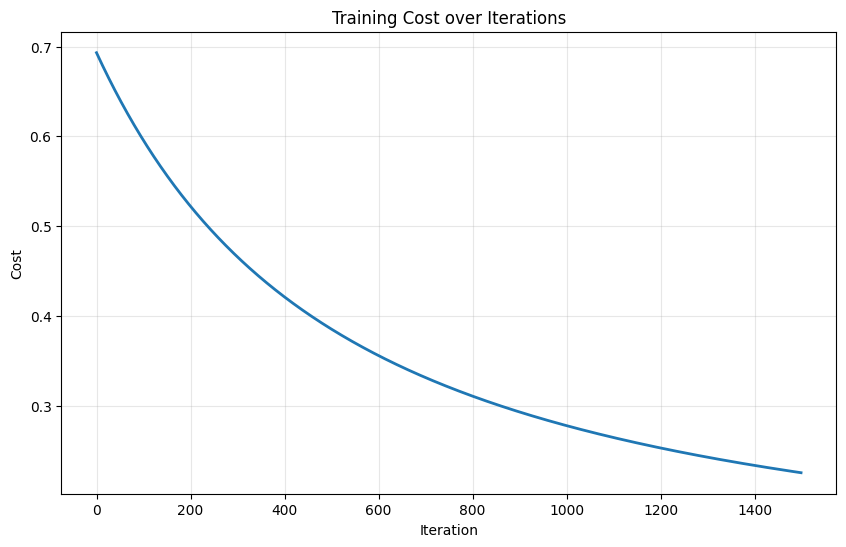

In [39]:

# 7️. Train the model

print("\nExtracting features for training set...")
X = np.zeros((len(train_x), 3))
for i in range(len(train_x)):
    X[i, :] = extract_features(train_x[i], freqs)

Y = train_y.reshape(-1, 1)
theta = np.zeros((3, 1))

print("\n" + "="*50)
print("TRAINING MODEL")
print("="*50)

J, theta, cost_history = gradient_descent(X, Y, theta, alpha=1e-9, num_iters=1500)

print("\n" + "="*50)
print(f"Final Training cost: {J:.8f}")
print(f"Trained theta: {theta.flatten()}")  
print("="*50)

# Plot training curve
plt.figure(figsize=(10, 6))
plt.plot(cost_history, linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Training Cost over Iterations')
plt.grid(True, alpha=0.3)
plt.show()


In [45]:
# 8. Make predictions
def predict_tweet(tweet, freqs, theta):
    """ predict probability of a tweet being positive"""
    x = extract_features(tweet, freqs)
    y_pred = sigmoid(np.dot(x, theta))
    return float(y_pred[0, 0])

# Test predictions
print("\n" + "="*50)
print("TEST PREDICTIONS")
print("="*50)
test_tweets = [
    'I love this!', 
    'I hate this!', 
    'This movie was amazing', 
    'This movie was terrible',
    'great great great',
    'I am happy :)',
    'I am sad :('
]
for t in test_tweets:
    pred = predict_tweet(t, freqs, theta)
    sentiment = "Positive" if pred > 0.5 else "Negative"
    print(f"{t:30s} -> {pred:.4f} ({sentiment})")





TEST PREDICTIONS
I love this!                   -> 0.5273 (Positive)
I hate this!                   -> 0.4949 (Negative)
This movie was amazing         -> 0.5037 (Positive)
This movie was terrible        -> 0.4986 (Negative)
great great great              -> 0.5480 (Positive)
I am happy :)                  -> 0.8413 (Positive)
I am sad :(                    -> 0.1085 (Negative)



TESTING ON TEST SET
Test set accuracy: 0.9965 (99.65%)


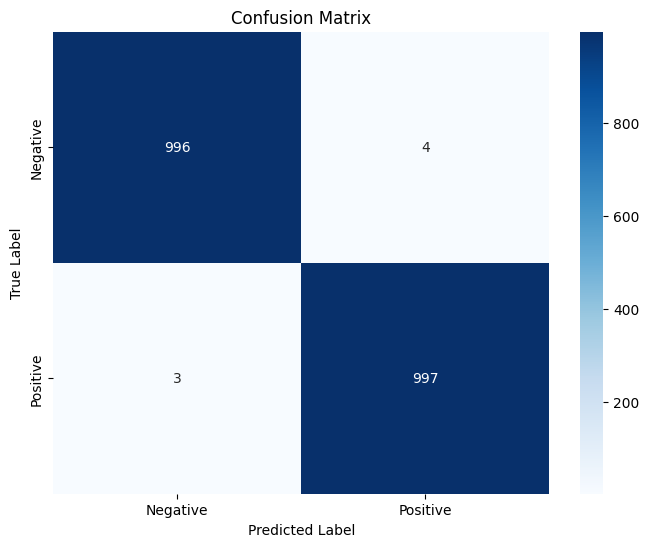


Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00      1000
    Positive       1.00      1.00      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [48]:
# 9. Test accuracy on the test set 

def test_logistic_regression(test_x, test_y, freqs, theta):
    """calculate the accuracy of logistic regression on test set"""
    y_hat = []
    y_probs = []

    for tweet in test_x:
        pred = predict_tweet(tweet, freqs, theta)
        y_hat.append(1.0 if pred > 0.5 else 0.0)
        y_probs.append(pred)
        
    y_hat = np.array(y_hat)
    accuracy = np.mean(y_hat == test_y.flatten())
    return accuracy, y_hat, np.array(y_probs)

print("\n" + "="*50)
print("TESTING ON TEST SET")
print("="*50)

acc, predictions, probabilities = test_logistic_regression(test_x, test_y, freqs, theta)
print(f"Test set accuracy: {acc:.4f} ({acc*100:.2f}%)")

# Confusion Matrix

from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(test_y, predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:")
print(classification_report(test_y, predictions, target_names=['Negative', 'Positive']))


In [49]:
# 10. Error Analysis

print("\n" + "="*   60)
print("ERROR ANALYSIS: MISCLASSIFIED TWEETS")
print("="*60)

errors = []
for i, (tweet, true_label) in enumerate(zip(test_x, test_y)):
    pred_prob = probabilities[i]
    pred_label = 1.0 if pred_prob > 0.5 else 0.0

    if pred_label != true_label:
        errors.append({
            'tweet': tweet,
            'true': 'POS' if true_label == 1.0 else 'NEG',
            'pred': 'POS' if pred_label == 1.0 else 'NEG',
            'prob': pred_prob
        })

print(f"Total errors: {len(errors)}/{len(test_y)}\n")

# Show first 10 errors
for i, e in enumerate(errors[:10]):
    print(f"{i+1}. TRUE: {e['true']} | PRED: {e['pred']} ({e['prob']:.3f})")
    print(f"   {e['tweet']}")
    print()



ERROR ANALYSIS: MISCLASSIFIED TWEETS
Total errors: 7/2000

1. TRUE: POS | PRED: NEG (0.489)
   @MarkBreech Not sure it would be good thing 4 my bottom daring 2 say 2 Miss B but Im gonna be so stubborn on mouth soaping ! #NotHavingit :p

2. TRUE: POS | PRED: NEG (0.496)
   off to the park to get some sunlight : )

3. TRUE: POS | PRED: NEG (0.482)
   @msarosh Uff Itna Miss karhy thy ap :p

4. TRUE: NEG | PRED: POS (0.510)
   @phenomyoutube u probs had more fun with david than me : (

5. TRUE: NEG | PRED: POS (0.500)
   pats jay : (

6. TRUE: NEG | PRED: POS (0.500)
   my beloved grandmother : ( https://t.co/wt4oXq5xCf

7. TRUE: NEG | PRED: POS (0.506)
   Sr. Financial Analyst - Expedia, Inc.: (#Bellevue, WA) http://t.co/ktknMhvwCI #Finance #ExpediaJobs #Job #Jobs #Hiring



In [57]:
# 11. Predicting on new tweets

print("\n" + "="*50)
print("PREDICTIONS ON NEW TWEETS")
print("="*50)           

my_tweets = [
    "I really enjoyed the movie! It was awesome :)",
    "This is terrible, I hate it",
    "Wow it's amazing!",
    "The worst day ever"
]

for tweet in my_tweets:
    pred_prob = predict_tweet(tweet, freqs, theta)
    sentiment = "😊 POSITIVE" if pred_prob > 0.5 else "😞 NEGATIVE"
    print(f"\n'{tweet}'")
    print(f"  Prediction: {sentiment} (probability: {pred_prob:.4f})")

print("\n" + "="*60)
print("🎉 PROJECT COMPLETE!")
print("="*60)


PREDICTIONS ON NEW TWEETS

'I really enjoyed the movie! It was awesome :)'
  Prediction: 😊 POSITIVE (probability: 0.8337)

'This is terrible, I hate it'
  Prediction: 😞 NEGATIVE (probability: 0.4937)

'Wow it's amazing!'
  Prediction: 😊 POSITIVE (probability: 0.5052)

'The worst day ever'
  Prediction: 😊 POSITIVE (probability: 0.5071)

🎉 PROJECT COMPLETE!
